In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer


In [2]:
def load_dataset():
 #Load the dataset.
 dataset = pd.read_csv("../BostonHousing.csv")
 dataset.info()
 return dataset

In [3]:
#Handlemissing values and outliers
def handeling_identified():
    df = load_dataset()
    
    #Handels missing datas though there are no misssing datas
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    ##Handle major outliers in crime rate column and black residents column
    Q1 = df['crim'].quantile(0.25)
    Q3 = df['crim'].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5 * IQR
    print(lower_bound)
    upper_bound = Q3 + 1.5 * IQR
    df['crim'] = np.where(df['crim'] > upper_bound, upper_bound,
                 np.where(df['crim'] < lower_bound, lower_bound, df['crim']))
    print(df['crim'].max())
    
    Q1 = df['b'].quantile(0.25)
    Q3 = df['b'].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df['b'] = np.where(df['b'] > upper_bound, upper_bound,
                 np.where(df['b'] < lower_bound, lower_bound, df['b']))
    
    plt.figure(figsize=(15, 8))
    sns.violinplot(data=df.select_dtypes(include=[np.number]))
    plt.xticks(rotation=45)
    plt.title("Violin Plots Showing Distributions and Outliers Handled")
    plt.show()

#handeling_identified()


In [4]:
def encodeed():
    df = load_dataset()
    df_encoded = df.copy()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    if 'chas' in df.columns and len(categorical_cols) == 0:
        categorical_cols = ['chas']
    if len(categorical_cols) > 0:
        print(f"Encoding categorical columns: {categorical_cols}")
              
        transformers = []
        for col in categorical_cols:
             if col == 'chas' and set(df[col].unique()).issubset({0, 1}):
                 print(f"Column '{col}' is already binary (0/1), skipping encoding")
                 continue
             if df[col].nunique() > 2:
                 print(f"One-hot encoding column: {col}")
                 encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
                 encoded = encoder.fit_transform(df[[col]])
                 encoded_df = pd.DataFrame(encoded, 
                                       columns=[f"{col}_{cat}" for cat in encoder.categories_[0]])
                 df_encoded = pd.concat([df_encoded.drop(col, axis=1), encoded_df], axis=1)

             else:
                 print(f"Binary encoding column: {col}")
                 df_encoded[col] = df[col].astype(int) if not df[col].dtype == int else df[col]
        return df_encoded.head()
#df_encoded = encodeed()
        



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


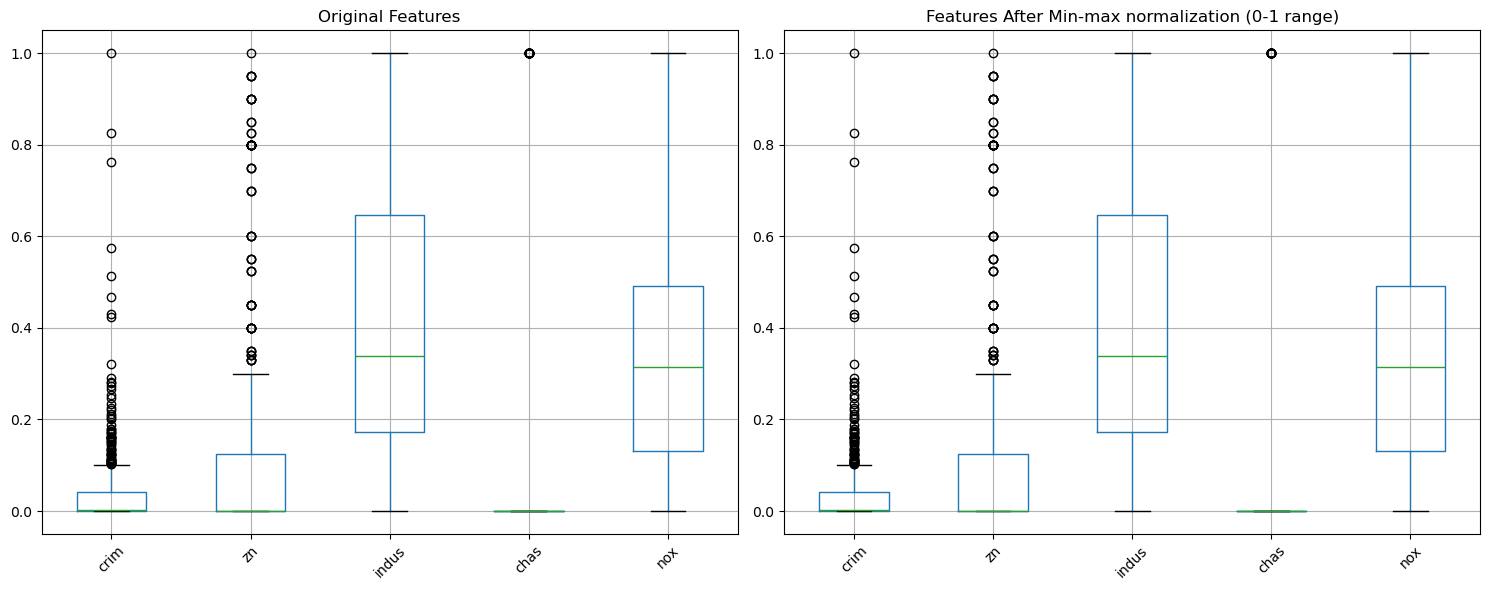

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


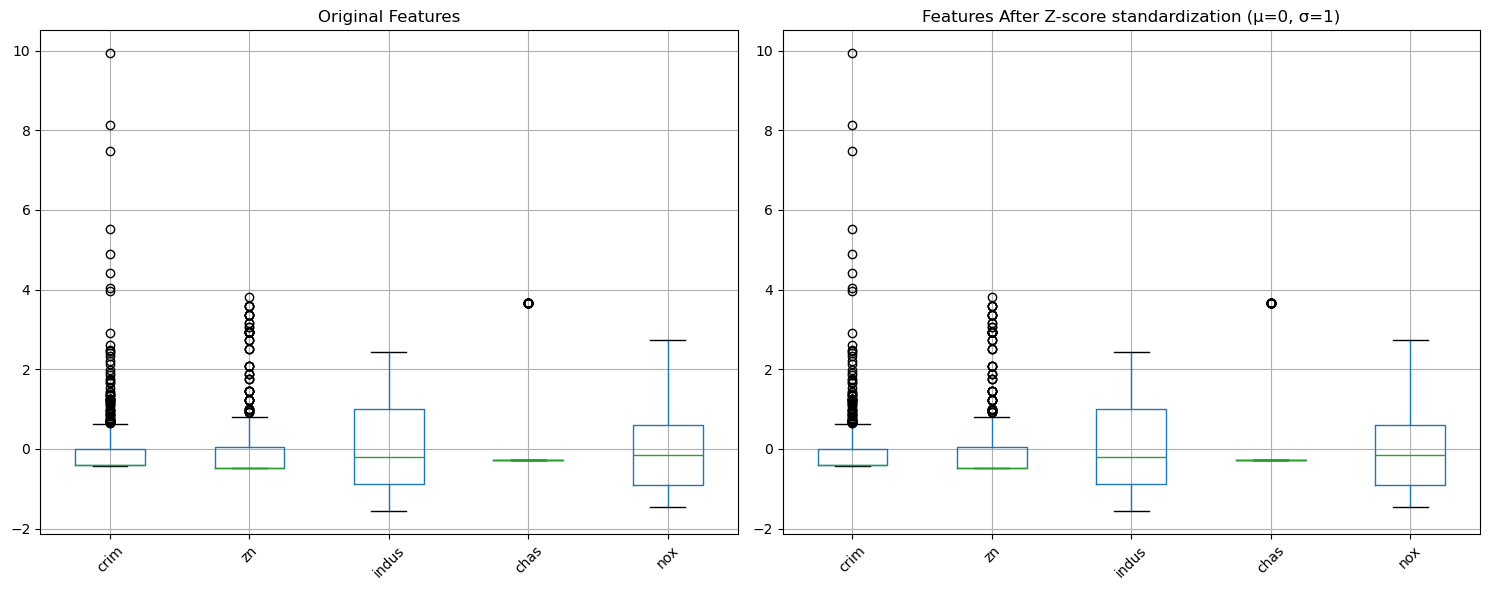

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,0.441052,-1.075562,24.0
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,0.441052,-0.492439,21.6
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,0.396427,-1.208727,34.7
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,0.416163,-1.361517,33.4
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,0.441052,-1.026501,36.2


In [5]:
def scale_features(method:str):
    df = load_dataset()
    target_col = 'medv'
    action = method
    numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in numerical_features:
        numerical_features.remove(target_col)
    if len(numerical_features) == 0:
        print("No numerical features to scale")
        return df
    #Initialize sccaler
    if action == 'standarize':
        scaler = StandardScaler()
        scaler_name = "Z-score standardization (μ=0, σ=1)"
    elif method == 'normalize':
        scaler = MinMaxScaler()
        scaler_name = "Min-max normalization (0-1 range)"

    df[numerical_features] = scaler.fit_transform(df[numerical_features])

    plt.figure(figsize = (15,6))

    # Before scaling
    plt.subplot(1, 2, 1)
    df[numerical_features[:5]].boxplot()  # Show first 5 features for clarity
    plt.title("Original Features")
    plt.xticks(rotation=45)
    
    # After scaling
    plt.subplot(1, 2, 2)
    df[numerical_features[:5]].boxplot()
    plt.title(f"Features After {scaler_name}")
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    return df.head()
scale_features('normalize')
scale_features('standarize')


    


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [7]:
def split_data():
    df = load_dataset()
    #given that  median value of owner-occupied homes in $1000s (Target).
    X = df.drop(columns=['medv'])
    Y = df['medv']

    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state= 42)
    return X_train.head(), X_test.head(), Y_train.head(), Y_test.head()
split_data()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


(         crim    zn  indus  chas     nox     rm   age     dis  rad  tax  \
 477  15.02340   0.0  18.10     0  0.6140  5.304  97.3  2.1007   24  666   
 15    0.62739   0.0   8.14     0  0.5380  5.834  56.5  4.4986    4  307   
 332   0.03466  35.0   6.06     0  0.4379  6.031  23.3  6.6407    1  304   
 423   7.05042   0.0  18.10     0  0.6140  6.103  85.1  2.0218   24  666   
 19    0.72580   0.0   8.14     0  0.5380  5.727  69.5  3.7965    4  307   
 
      ptratio       b  lstat  
 477     20.2  349.48  24.91  
 15      21.0  395.62   8.47  
 332     16.9  362.25   7.83  
 423     20.2    2.52  23.29  
 19      21.0  390.95  11.28  ,
         crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
 173  0.09178   0.0   4.05     0  0.510  6.416  84.1  2.6463    5  296   
 274  0.05644  40.0   6.41     1  0.447  6.758  32.9  4.0776    4  254   
 491  0.10574   0.0  27.74     0  0.609  5.983  98.8  1.8681    4  711   
 72   0.09164   0.0  10.81     0  0.413  6.065   7.8  5.287